# Logistic Regression From Scratch
### RoadMap
1. Load and explore data
2. The logistic regression model
3. Loss function(Binary cross-entrophy)
4. Gradient derivation
6. Training and validation

# Imports

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import pprint
import pickle
import os


# download dataset from kaggel and load it on loacal machine

In [4]:
import kagglehub
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
print("path: ", path)

csv_filename = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_filename)

df = pd.read_csv(full_csv_path)

print("\nDataset loaded successfully.")
print("Dataset shape: ", df.shape)


path:  /Users/himukottra/.cache/kagglehub/datasets/yasserh/breast-cancer-dataset/versions/1

Dataset loaded successfully.
Dataset shape:  (569, 32)


In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## plot the class of Diagnosis

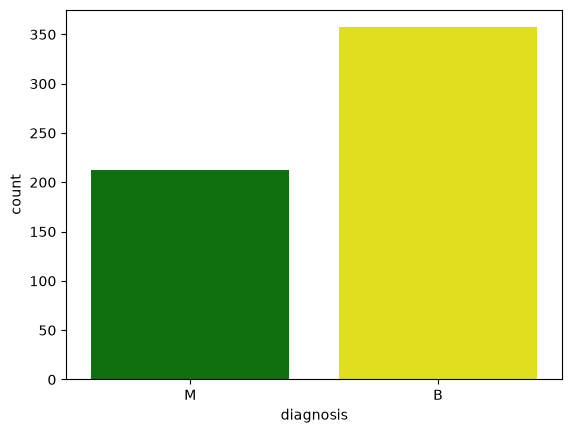

In [15]:
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette=['green', 'yellow'], legend=False)
plt.show()


## Data preprocessing

In [16]:
# Remove the 'id' column from the DataFrame
df.drop('id', axis=1, inplace=True)

In [17]:
# transform the 'diagnosis' column to binary values: 1 for malignant (M) and 0 for benign (B)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

### lets see the highly correlated features with the target

In [19]:
corr = df.corr()

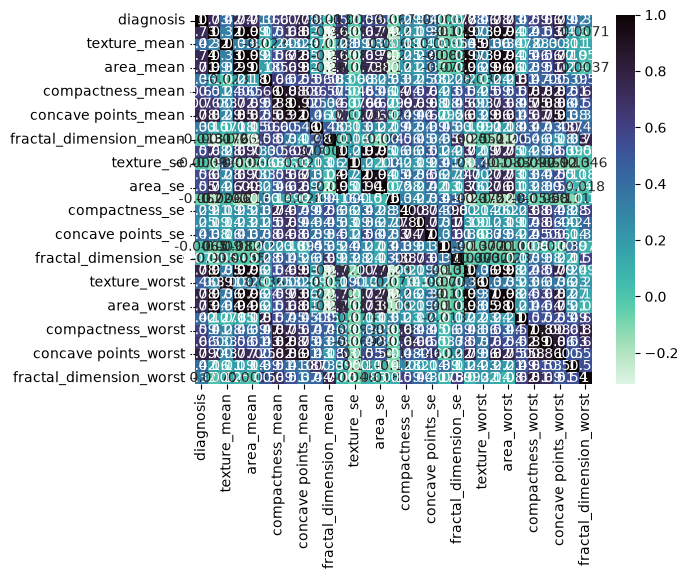

In [38]:
plt.Figure(figsize=(24, 20))
sns.heatmap(corr, cmap = 'mako_r', annot=True)
plt.show()

In [ ]:
# Extract the absolute correlation values of all features with respect to the target variable 'diagnosis'
cor_target = abs(corr['diagnosis'])

# Select features that have a correlation greater than 0.2 with the target variable
relevant_features = cor_target[cor_target > 0.2]



# create a list of feature names that have a correlation greater than 0.2 with the target variable
names = [index for index, value in relevant_features.items()]

names.remove('diagnosis')  # Remove the target variable from the list of features, keep only predictor features

pprint.pprint(names)

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']


In [42]:
X =df[names].values # create dataframe with only the relevant features values
y = df['diagnosis'].values # create dataframe with only the target variable values

## Train test split


In [44]:
def train_test_split(X, y, random_state=42, test_size=0.2):


    n_samples = X.shape[0] # return the number of samples in the dataset

    np.random.seed(random_state) # set the random seed for reproducibility


    # an.arange(n_samples) creates an array of integers from 0 to n_samples-1, 
    # representing the indices of the samples in the dataset.
    # np.random.permutation() shuffles the array of indices randomly,
    #  creating a new array of shuffled indices.

    shuffled_indices = np.random.permutation(np.arange(n_samples))

    # determine the test size
    test_size = int(n_samples * test_size)

    
    test_indices = shuffled_indices[:test_size] # select the first test_size indices for the test set
    train_indices = shuffled_indices[test_size:] # select the remaining indices for the training set

    X_train, X_test = X[train_indices], X[test_indices] # split the features into training and test sets
    y_train, y_test = y[train_indices], y[test_indices] # split the target variable into training and test sets


    return X_train, X_test, y_train, y_test # return the training and test sets



In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y,)

# Standardize The Data

$$\text{Standardized Value} = \frac{x - \mu}{\sigma}$$
 x = data points
 $\mu$ = mean
 $\sigma$ = standard deviation

In [2]:
def standardize_data(X_train, X_test):

    # Calculate the mean and standard deviation of the training data
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0) # axis=0 means we are calculating the mean and std for each
    #feature (column) across all samples (rows)

    
    X_train = (X_train - mean) / std # standardize the training data
    X_test = (X_test - mean) / std # standardize the test data using the training mean and std

    return X_train, X_test # return the standardized training and test data

X_train, X_test = standardize_data(X_train, X_test)

NameError: name 'X_train' is not defined